# **Business Understanding**

Principal Component Analysis (PCA) is a dimensionality reduction technique used to simplify complex datasets. It reduces the number of variables (features) while retaining the most important information, transforming correlated features into a smaller set of uncorrelated variables called principal components. 

**Context**
Everybody nowadays is mindful of what they eat. Counting calories and reducing fat intake is the number one advice given by all dieticians and nutritionists. Therefore, we need to know what foods are rich in what nutrients, don't we?

The dataset contains a csv file with more than 300 foods each with the amount of Calories, Fats, Proteins, Saturated Fats, Carbohydrates, Fibers labelled for each food. Also, the foods are also categorised into various groups like Desserts, Vegetables, Fruits etc.

**Task**
Use PCA to discover which nutrients explain most of the variation across foods and whether foods with similar nutritional  profiles group together

**Data Source**
[Data Source](https://www.kaggle.com/datasets/niharika41298/nutrition-details-for-most-common-foods)

## Load required libraries**

In [86]:
import pandas as pd 
import numpy as np   
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier 
from sklearn.cluster import KMeans # For modelling

## **Load Data**

In [87]:
df = pd.read_csv("nutrients_csvfile.csv")
df.shape

(335, 10)

## **View and prepare data**

In [88]:
df.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


In [89]:
df.tail()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
330,Fruit-flavored soda,12 oz.,346,161,0,0,0,0,42,"Drinks,Alcohol, Beverages"
331,Ginger ale,12 oz.,346,105,0,0,0,0,28,"Drinks,Alcohol, Beverages"
332,Root beer,12 oz.,346,140,0,0,0,0,35,"Drinks,Alcohol, Beverages"
333,Coffee,1 cup,230,3,t,0,0,0,1,"Drinks,Alcohol, Beverages"
334,Tea,1 cup,230,4,0,t,0,0,1,"Drinks,Alcohol, Beverages"


In [90]:
df.columns

Index(['Food', 'Measure', 'Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat',
       'Fiber', 'Carbs', 'Category'],
      dtype='str')

In [91]:
df.keys()

Index(['Food', 'Measure', 'Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat',
       'Fiber', 'Carbs', 'Category'],
      dtype='str')

In [92]:
df.dtypes

Food        str
Measure     str
Grams       str
Calories    str
Protein     str
Fat         str
Sat.Fat     str
Fiber       str
Carbs       str
Category    str
dtype: object

In [93]:
df.describe()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
count,335,335,335,334,335,335,333,335,335,335
unique,329,61,103,152,40,45,38,57,80,16
top,Butter,1 cup,100,100,1,t,0,0,0,"Breads, cereals, fastfood,grains"
freq,3,120,38,14,53,115,174,116,45,45


In [94]:
df.Calories

0        660
1        360
2        127
3        345
4      1,373
       ...  
330      161
331      105
332      140
333        3
334        4
Name: Calories, Length: 335, dtype: str

## **# Select nutrient columns**

In [95]:
features = ["Calories", "Protein", "Fat",  "Sat.Fat", "Carbs", "Fiber"]
X = df[features] # Create X

In [96]:


categories = df["Category"]


## **Standardize the Data**

In [97]:


#  Add Grouping
def simplify_category(cat):
    if "Vegetables" in cat:
        return "Vegetables"
    elif "Fruits" in cat:
        return "Fruits"
    elif "Meat" in cat or "Fish" in cat:
        return "Protein Foods"
    elif "Desserts" in cat or "Jams" in cat:
        return "Sugary Foods"
    elif "Fats" in cat:
        return "Fats/Oils"
    else:
        return "Other"

df["SimpleCategory"] = df["Category"].apply(simplify_category)


## **Cleaning data before scaling**

In [98]:
# Remove commas and convert to float. Current dataset is of type string

# Cleans each column properly
import numpy as np

def clean_numeric(value):
    value = str(value)
    
    # Remove commas
    value = value.replace(",", "")
    
    # Handle ranges like "8-44"
    if "-" in value:
        try:
            nums = [float(v) for v in value.split("-") if v.strip() != ""]
            return sum(nums) / len(nums)
        except:
            return np.nan
    
    # Convert to float
    try:
        return float(value)
    except:
        return np.nan

# Apply cleaning
X = X.apply(lambda col: col.map(clean_numeric))

# Handle missing values
X = X.fillna(X.mean())

## **Validate the data before scaling**

In [99]:

print(X.dtypes)
print(X.head())


Calories    float64
Protein     float64
Fat         float64
Sat.Fat     float64
Carbs       float64
Fiber       float64
dtype: object
   Calories  Protein        Fat    Sat.Fat  Carbs  Fiber
0     660.0     32.0  40.000000  36.000000   48.0    0.0
1     360.0     36.0  13.063927   6.742138   52.0    0.0
2     127.0      9.0   5.000000   4.000000   13.0    0.0
3     345.0     16.0  20.000000  18.000000   24.0    0.0
4    1373.0     89.0  42.000000  23.000000  119.0    1.4


## **Insight**
- All are of type float64
- Now we can work on the dataset

In [100]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## **PCA**

In [101]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

## **Plotting PCA Clusters**

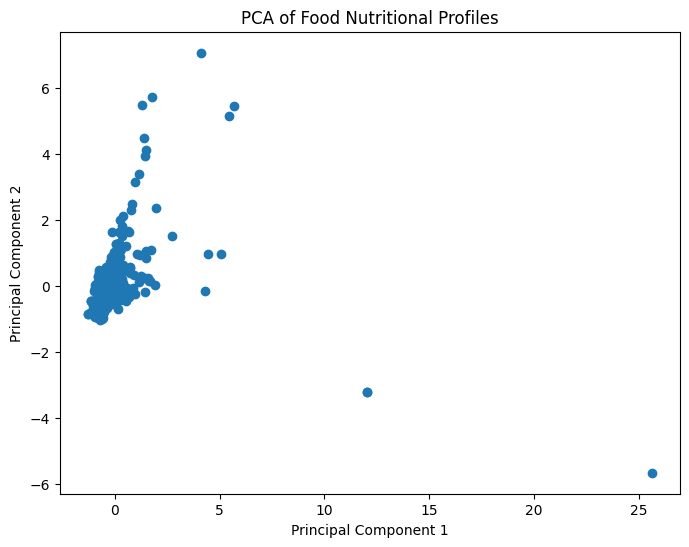

In [102]:
# Plot first two principal components
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Food Nutritional Profiles")

plt.show()


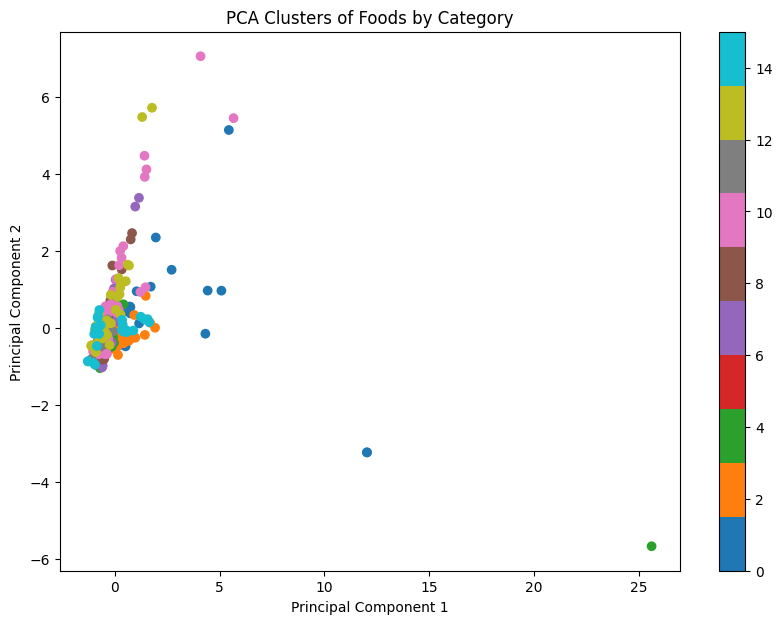

In [103]:
# Coloring food by food category

# Convert categories to numeric labels
labels = pd.factorize(df["Category"])[0]

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=labels, 
    cmap='tab10'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Clusters of Foods by Category")

plt.colorbar(scatter)
plt.show()

## **Food clusters based on nutritional profiles**

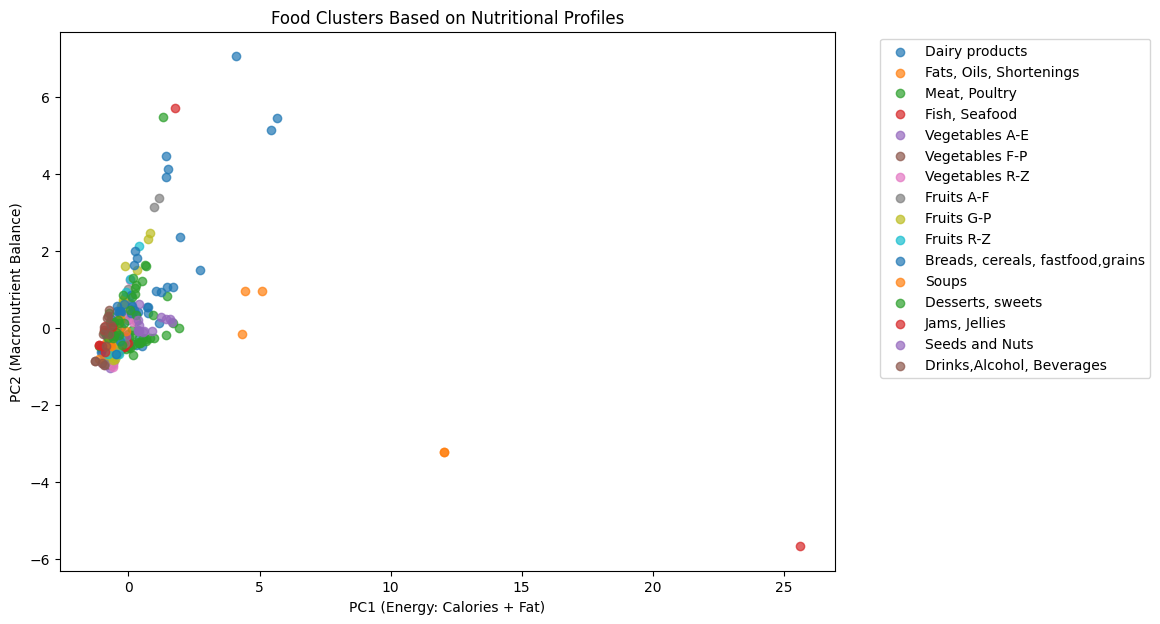

In [104]:
plt.figure(figsize=(10,7))

for category in df["Category"].unique():
    idx = df["Category"] == category
    plt.scatter(
        X_pca[idx, 0], 
        X_pca[idx, 1], 
        label=category,
        alpha=0.7
    )

plt.xlabel("PC1 (Energy: Calories + Fat)")
plt.ylabel("PC2 (Macronutrient Balance)")
plt.title("Food Clusters Based on Nutritional Profiles")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

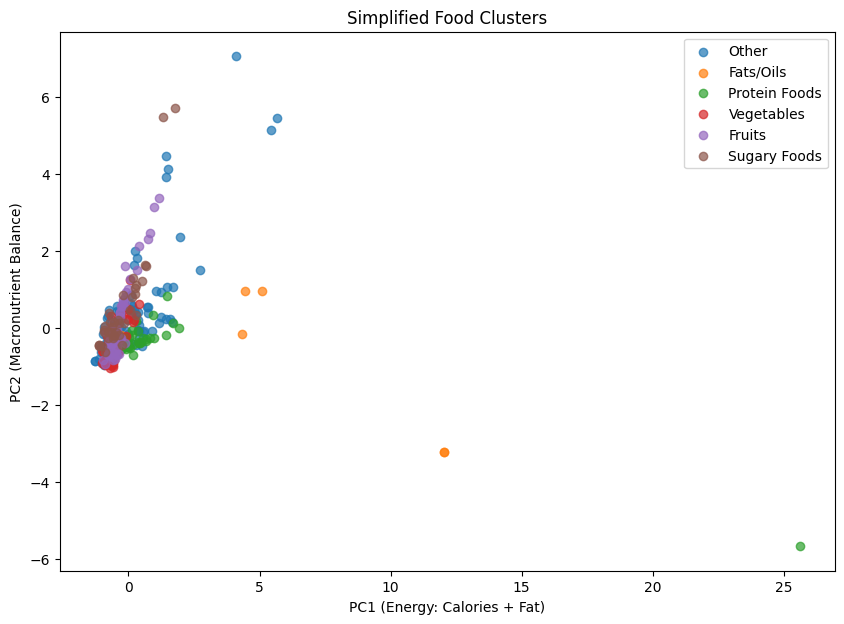

In [105]:
plt.figure(figsize=(10,7))

for category in df["SimpleCategory"].unique():
    idx = df["SimpleCategory"] == category
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=category,
        alpha=0.7
    )

plt.xlabel("PC1 (Energy: Calories + Fat)")
plt.ylabel("PC2 (Macronutrient Balance)")
plt.title("Simplified Food Clusters")

plt.legend()
plt.show()


## **Key Insights**

# Fats/Oils – Strong Outliers
- Clearly separated far on the right (high PC1)
- Represent very high calories and fat content
-  These foods dominate the energy dimension and are the most nutritionally distinct

# Protein Foods – Distinct but Less Extreme
- Spread slightly right and vertically
- Higher values along PC2 (nutrient balance)
- Protein foods are structurally different due to high protein composition, not just calories

# Sugary Foods – Moderately Energy-Dense
- Positioned right of center, but not as far as fats/oils
- Overlap with other groups
- Sugary foods are calorie-rich but less extreme, and share similarities with other food types

# Fruits – High PC2 Spread
- Extend upwards along PC2
- Fruits show variation driven by fiber/carbohydrate content, distinguishing them nutritionally

# Vegetables – Tight Cluster Near Origin
- Concentrated around low PC1 and PC2
- Vegetables are low-calorie and nutritionally consistent, forming a compact cluster

# Other Foods – Mixed Distribution
- Spread across central and upper regions
- Represents heterogeneous foods with mixed nutritional profiles

# Overall Interpretation
- PC1 (Calories + Fat) is the strongest separator of food types
- PC2 (Macronutrient balance) distinguishes protein-rich vs carb/fiber-rich foods
- Clear separation exists for extreme foods (fats/oils)
- Most food groups overlap → showing shared nutritional characteristics
- Clustering confirms that nutritional composition drives food similarity

- Foods cluster into distinct groups based on energy density and macronutrient composition, with fats and oils forming clear outliers, while most other food categories show overlapping but interpretable nutritional patterns.

## ** Show Food and Nutrients**

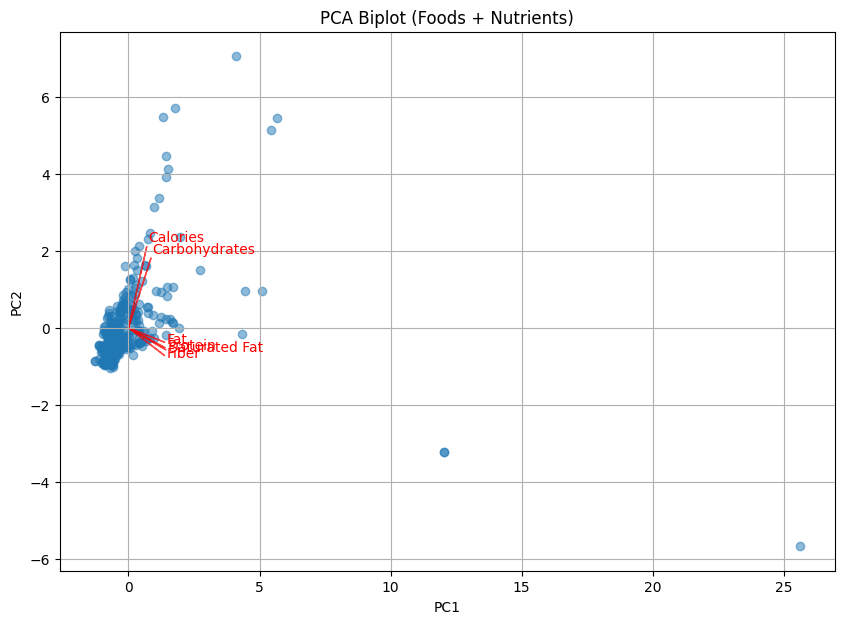

In [106]:
plt.figure(figsize=(10,7))

# Scatter
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)

# Add feature vectors
features = ["Calories", "Fat", "Protein", "Saturated Fat", "Carbohydrates", "Fiber"]

for i, feature in enumerate(features):
    plt.arrow(0, 0, 
              pca.components_[0, i]*3, 
              pca.components_[1, i]*3,
              color='red', alpha=0.7)
    
    plt.text(
        pca.components_[0, i]*3.2, 
        pca.components_[1, i]*3.2, 
        feature, 
        color='red'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot (Foods + Nutrients)")

plt.grid()
plt.show()


## **Modelling the Data - Clustering Modelling**

# Use K-Means Clustering

In [ ]:
# Choose number of clusters
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add clusters to dataframe
df["Cluster"] = clusters


## **Plot the clusters**

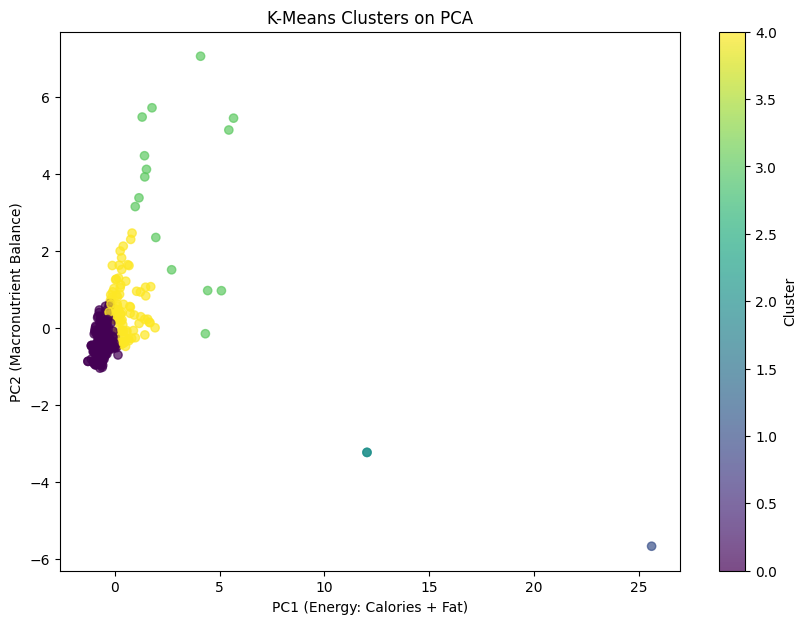

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("PC1 (Energy: Calories + Fat)")
plt.ylabel("PC2 (Macronutrient Balance)")
plt.title("K-Means Clusters on PCA")

plt.colorbar(label="Cluster")
plt.show()

## ** Key Insights for K-Means Cluster Interpretation**

# Cluster 0 (Dark Purple – Dense Core Cluster)
- Located tightly around low PC1 and low PC2
- Contains the largest number of foods
- Characteristics: Low to moderate calories and Balanced nutrients
- Interpretation: Represents “everyday balanced foods” and Includes: vegetables, grains, some fruits

# Cluster 4 (Yellow – Moderate Energy Cluster)
- Slightly right and above the central cluster
- Spread along PC2
- Characteristics: Moderate calories and Variation in carbs/fiber
- Interpretation: Represents carb-rich and mixed foods and Includes: fruits, grains, some sugary foods

# Cluster 3 (Green – High PC2 Cluster)
- Positioned high up on PC2 (vertical separation)
- Characteristics: Strong variation in macronutrient balance and Likely high protein or fiber
- Interpretation: Represents protein-rich or fiber-dense foods and Includes: meat, fish, dairy, high-fiber foods

# Cluster 2 (Teal – Extreme Outlier Cluster)
- Very far from center: Around PC1 ≈ 12, PC2 ≈ -3
- Characteristics: Very high energy but unusual nutrient balance
- Interpretation: Represents highly processed or extreme foods and These are rare but influential

# Cluster 1 (Blue – Extreme Energy Outlier)
- Extremely far on PC1 (≈ 26)
- Characteristics: Extremely high calories and fat
- Interpretation: Represents pure fats/oils or very energy-dense foods and Strongest outlier in dataset

# Overall Insights 
- K-Means successfully grouped foods into:
 - 1. Balanced foods
 - 2. Carbohydrate-rich foods
 - 3. Protein/fiber-rich foods
 - 4. High-energy outliers

# 2. Energy (PC1) Drives Extreme Separation
- Right side clusters = high fat/calorie foods
 - Confirms PCA finding:
 - Calories + fat dominate variation

# 3. Macronutrient Balance (PC2) Defines Structure
- Vertical spread separates: Protein vs carbs/fiber foods

# 4. Majority of Foods Are Similar
- Large cluster near origin shows: Most foods have moderate, balanced nutrition

# 5. Outliers Are Very Important
- Few extreme foods sit far away
 - These:
   - Influence PCA strongly
   - Represent unhealthy or specialized foods

- The K-Means clustering results reveal distinct groupings of foods based on nutritional composition. A large central cluster represents foods with balanced nutrient profiles, while separate clusters capture energy-dense foods and those with distinct macronutrient compositions such as protein-rich or carbohydrate-rich foods. Extreme outliers, particularly high-fat foods, are clearly separated, highlighting their disproportionate influence on nutritional variation.

# Simple Summary 
- Cluster 0 → Balanced foods
- Cluster 4 → Carb/mixed foods
- Cluster 3 → Protein/fiber-rich foods
- Cluster 2 → Processed/extreme foods
- Cluster 1 → High-fat/high-calorie outliers


## **K-Means being an unsupervised machile learning method has no accuracy like classification models**
- Since K-Means is an unsupervised learning technique, traditional accuracy metrics are not applicable. Instead, clustering performance is evaluated using measures such as the Silhouette Score, which assesses how well data points fit within their assigned clusters.

In [114]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, clusters))


0.3934698271830715


## ** Insight**
- The silhouette score of 0.393 indicates moderate clustering performance. This suggests that while the K-Means algorithm is able to identify meaningful groupings based on nutritional composition, there is notable overlap between clusters. This is expected given the inherent similarity in nutrient profiles across many food categories.

## **Classification Model**

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Use labels (SimpleCategory)
y = df["SimpleCategory"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7014925373134329


## **Key Insights**

# Accuracy = 0.701 (≈ 70.15%)

##  1. Nutrients Can Predict Food Categories
- The model correctly classifies foods 70.15% of the time
- Nutritional features are strong predictors

## 2. Not Perfect → Overlapping Profiles
- Some foods look similar nutritionally
- Example:
  - Fruits vs vegetables
  - grains vs sugary foods
- This leads to misclassification


## 3. Real-World Complexity Reflected
- Food categories are not strictly separable
- Many foods share: Carbs, fats and proteins

- The classification model achieved an accuracy of approximately 70%, indicating that nutritional attributes such as calories, fat, protein, carbohydrates, and fiber provide a reasonably strong basis for predicting food categories. However, the less-than-perfect accuracy suggests overlap in nutritional profiles across different food groups, highlighting the complexity of real-world dietary data.